## Device

In [1]:
shared_folder_Path = "/media/marina/01DB47DC6EBB7DC0/ThreeD/shared"[:-6]
path = '/media/marina/01DB47DC6EBB7DC0/0_Data/conp-dataset/projects/calgary-campinas/CC359/Raw-data/Single-channel/IM_MoCo/'
path_model= '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/1_Unet_InstanceNorm/'
import sys,os, glob, torch
import pickle
sys.path.insert(1,shared_folder_Path)
try:
    os.mkdir('')
except:
    pass

paths_train = glob.glob(path + "/train/*")
paths_test  = glob.glob(path + "/test/*")
paths_test_low = [p for p in paths_test if ('motion_5' in p)]
paths_test_mid = [p for p in paths_test if ('motion_15' in p)]
paths_test_hgh = [p for p in paths_test if ('motion_25' in p)]
len(paths_train), len(paths_test_low), len(paths_test_hgh),len(paths_test)

(3, 400, 400, 1200)

## Import

In [2]:
%load_ext autoreload
%autoreload 2

from torcheval.metrics import PeakSignalNoiseRatio
import torch
from torch.optim import lr_scheduler
from torch.autograd import Variable
import numpy as np
import random
from tqdm import tqdm
import nibabel as nib
from shared.plot import plot_2_Imgs, plot_3_Imgs, plot_4_Imgs, plot_Img
from torch.utils.data import Dataset, DataLoader
from shared.ssim import SSIM
ssim_calc = SSIM()
from torchvision import transforms
import torch.nn.functional as F
from scipy import ndimage
sys.path.append('src/')


def get_n_params( model):
    pp=0
    for p in list(model.parameters()):
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn

    return pp


# Deterministic for spectral norm
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
def init_seeds(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(0)
    # no change in alg
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
init_seeds(42)

## Data

In [3]:
import torch
from torch.fft import fftn, fftshift, ifftn, ifftshift
import torchvision
import torch.nn.functional as F

vflip = lambda a: torchvision.transforms.functional.vflip(a)
hflip = lambda a: torchvision.transforms.functional.hflip(a)


def pad(arr,pad_to):

    arr = F.pad( arr, ((pad_to-arr.shape[1])//2, (pad_to-arr.shape[1])//2,
                       (pad_to-arr.shape[0])//2, (pad_to-arr.shape[0])//2), mode='constant', value=0)

    return arr


def real_2_complex_shape(arr):
    if(len(arr.shape)==4 and arr.shape[1]==2):
        k_out2 = arr[:,0:1,:,:] + 1j* arr[:,1:2,:,:]
    if(len(arr.shape)==3 and arr.shape[0]==2):
        k_out2 = arr[0:1,:,:] + 1j* arr[1:2,:,:]

    return k_out2

def print_mini_maxi(arr):
    print(arr.min(), arr.max())
    
def FFT(x):
    return fftshift(fftn(ifftshift(x, dim=(-2, -1)), dim=(-2, -1)), dim=(-2, -1))


def IFFT(x):
    return ifftshift(ifftn(fftshift(x, dim=(-2, -1)), dim=(-2, -1)), dim=(-2, -1))


def norm_0_1(arr):
    arr = ((arr - arr.min()) / (arr.max()-arr.min()))
    return arr
def norm_1_1(arr):
    arr = ((arr - arr.min()) / (arr.max()-arr.min()))*2-1
    return arr


def normImg(x: torch.Tensor):

    # group norm
    c, h, w = x.shape
    x = x.reshape(1, c // 1 * h * w)
  
    mean = x.mean(dim=2).view(1, 1, 1)
    std = x.std(dim=2).view(1, 1, 1)
    x = x.view(c, h, w)
  
  
    return (x - mean) / std, mean, std


def convert_polar_to_cylindrical( magnitude, phase):

    real = magnitude * torch.cos(phase)
    imag = magnitude * torch.sin(phase)
    return real, imag


def convert_cylindrical_to_polar(real,imag):

    mag = (real ** 2 + imag ** 2) ** (0.5)
    phase = torch.atan2(imag, real)
    phase[phase.ne(phase)] = 0.0  # remove NANs if any
    return mag, phase

def normalized_complex_mag(arr):

    mag, phase = convert_cylindrical_to_polar(arr.real,arr.imag)
    normalized_magnitude = (mag - torch.mean(mag)) / (torch.std(mag))
    real,imag = convert_polar_to_cylindrical(normalized_magnitude,phase)
    normed = real+1j*imag 

    return normed


In [4]:
def preprocess(kspace, k_space_artifact,Main_Artifact_path,mask):

    # IFFT
    image_Complex = IFFT(kspace)
    image_artifact_Complex = IFFT(k_space_artifact)
    
    # Img
    image = image_Complex.abs()
    image_artifact = image_artifact_Complex.abs()
    
    # Norm img
    image = norm_0_1(image)
    image_artifact = norm_0_1(image_artifact)
    

    # View
    kspace = torch.view_as_real(kspace)
    kspace = torch.moveaxis(kspace,-1,0)
    k_space_artifact = torch.view_as_real(k_space_artifact)
    k_space_artifact = torch.moveaxis(k_space_artifact,-1,0)
    image_Complex = torch.view_as_real(image_Complex)
    image_Complex = torch.moveaxis(image_Complex,-1,0)
    image_artifact_Complex = torch.view_as_real(image_artifact_Complex)
    image_artifact_Complex = torch.moveaxis(image_artifact_Complex,-1,0)


    return  {"Arr":image[None,...],
             "Arr_Complex":image_Complex,
                "Art":image_artifact[None,...],
             "Art_Complex":image_artifact_Complex,
                "K_Arr":kspace,
                "K_Art":k_space_artifact,
                'path':Main_Artifact_path,
            }

class MRIDataset(Dataset):
    def __init__(self, imgs_paths):
        self.imgs_paths = imgs_paths
    def __len__(self):
        return len(self.imgs_paths)
    def __getitem__(self, index):

        Main_Artifact_path = self.imgs_paths[index]
        kspace,k_space_artifact,mask = torch.load(Main_Artifact_path, weights_only=False)
        return  preprocess(kspace,k_space_artifact,Main_Artifact_path, mask)

3 1200
/media/marina/01DB47DC6EBB7DC0/0_Data/conp-dataset/projects/calgary-campinas/CC359/Raw-data/Single-channel/IM_MoCo//test/e14258s3_P76800.7._slice_78_motion_25.pt
BLUR:  tensor([0.2126])


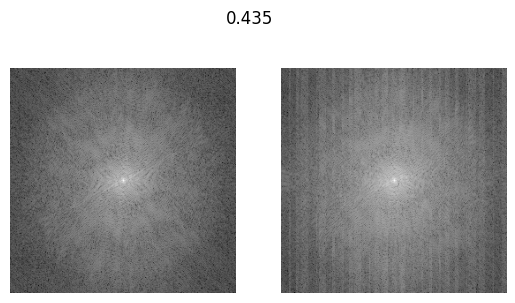

BLUR:  tensor([0.4792])


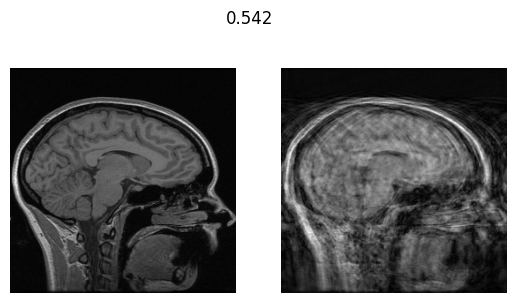

In [5]:
#dataset
dataset_train = MRIDataset(paths_train)
dataset_val = MRIDataset(paths_test)
print(len(dataset_train), len(dataset_val))

#dataloaders
batch_size = 1
dataloaders = dict()
dataloaders['train'] = DataLoader(dataset_train, batch_size=batch_size,
                                   shuffle=True, pin_memory=True)
dataloaders['val'] = DataLoader(dataset_val, batch_size=batch_size,
                                shuffle=False, pin_memory=True)
sample = dataset_val[random.randint(0,len(dataset_val))]

device = 'cuda'    
with torch.no_grad():
    print(sample['path'])
    Arr = sample['Arr'][None].to(device)
    Art = sample['Art'][None].to(device)
    
    K_Art = sample['K_Art'].to(device)
    K_Arr = sample['K_Arr'].to(device)
    K_Art = torch.view_as_complex(torch.moveaxis(K_Art,0,-1))
    K_Arr = torch.view_as_complex(torch.moveaxis(K_Arr,0,-1))
    
    plot_2_Imgs(K_Arr.abs().add(1e-9).log(),K_Art.abs().add(1e-9).log())
    plot_2_Imgs(Arr,Art)

## Model

/tmp/ipykernel_5701/3478821397.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC3

8556353
-1034


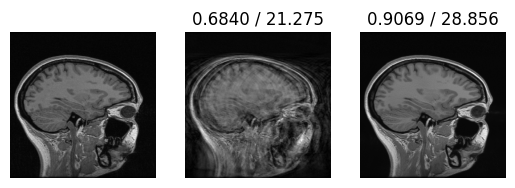

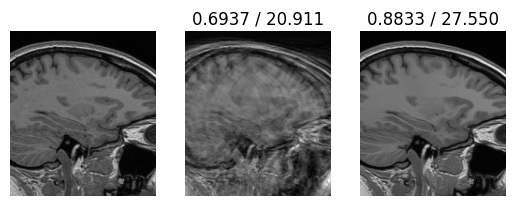

In [6]:
from unet_code import *
model = U_Net(1)#.cuda()
model = torch.load('/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/1_Unet_InstanceNorm/29model.pt','cpu')
print(get_n_params(model))
p = -1034#random.randint(0,len(dataset_val))
print(p)


sample= dataset_val[p]
device = 'cpu'   
with torch.no_grad():
    Img_arr = sample['Arr'][None].to(device)
    Art = sample['Art'][None].to(device)
    
    Real_out = model(Art)    

    torch.save(Img_arr,'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/Img_arr_' + str(p) +'.pt')
    torch.save(Img_arr[:,:,30:-63,30:-70],'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/Img_arr_sm_' + str(p) +'.pt')

    torch.save(Art,'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/Art_' + str(p) +'.pt')
    torch.save(Art[:,:,30:-63,30:-70],'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/Art_sm_' + str(p) +'.pt')

    torch.save(Real_out,'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/UNET_' + str(p) +'.pt')
    torch.save(Real_out[:,:,30:-63,30:-70],'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/UNET_sm_' + str(p) +'.pt')
   
    plot_3_Imgs(sample['Arr'][0],sample['Art'][0],Real_out[0,0])
    plot_3_Imgs(sample['Arr'][:,30:-50,50:-50],sample['Art'][:,30:-50,50:-50],Real_out[:,:,30:-50,50:-50])


In [8]:
f = "/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/6_Hybrid_Prior/Ablation/Data/"

torch.save(Img_arr,f+'/Img_arr_' + str(p) +'.pt')
torch.save(Img_arr[:,:,30:-63,30:-70],f+'/Img_arr_sm_' + str(p) +'.pt')

torch.save(Art,f+'/Art_' + str(p) +'.pt')
torch.save(Art[:,:,30:-63,30:-70],f+'/Art_sm_' + str(p) +'.pt')

torch.save(Real_out,f+'/UNET_' + str(p) +'.pt')
torch.save(Real_out[:,:,30:-63,30:-70],f+'/UNET_sm_' + str(p) +'.pt')


## Outer

In [7]:
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)


input_img_3DNuFFT_sub8_run04 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-08/input_img_3DNuFFT_run04.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub8_run04.shape)
input_img_3DNuFFT_sub8_run04 = torch.view_as_complex(input_img_3DNuFFT_sub8_run04)
print(input_img_3DNuFFT_sub8_run04.shape)
input_img_3DNuFFT_sub8_run04 = F.pad( input_img_3DNuFFT_sub8_run04, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub8_run04.shape)

input_img_3DNuFFT_sub8_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-08/input_img_3DNuFFT_run00.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub8_run00.shape)
#input_img_3DNuFFT_sub8_run00 = torch.view_as_complex(input_img_3DNuFFT_sub8_run00)
print(input_img_3DNuFFT_sub8_run00.shape)
input_img_3DNuFFT_sub8_run00 = F.pad( input_img_3DNuFFT_sub8_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub8_run00.shape)


input_img_3DNuFFT_sub1_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-01/sub-01_run-00_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub1_run00.shape)
input_img_3DNuFFT_sub1_run00 = torch.view_as_complex(input_img_3DNuFFT_sub1_run00)
print(input_img_3DNuFFT_sub1_run00.shape)
input_img_3DNuFFT_sub1_run00 = F.pad( input_img_3DNuFFT_sub1_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub1_run00.shape)

input_img_3DNuFFT_sub1_run01 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-01/sub-01_run-02_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub1_run01.shape)
input_img_3DNuFFT_sub1_run01 = torch.view_as_complex(input_img_3DNuFFT_sub1_run01)
print(input_img_3DNuFFT_sub1_run01.shape)
input_img_3DNuFFT_sub1_run01 = F.pad( input_img_3DNuFFT_sub1_run01, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub1_run01.shape)


input_img_3DNuFFT_sub2_run02 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-02_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub2_run02.shape)
input_img_3DNuFFT_sub2_run02 = torch.view_as_complex(input_img_3DNuFFT_sub2_run02)
print(input_img_3DNuFFT_sub2_run02.shape)
input_img_3DNuFFT_sub2_run02 = F.pad( input_img_3DNuFFT_sub2_run02, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub2_run02.shape)


input_img_3DNuFFT_sub2_run01 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-01_imgspace.pt','cpu',weights_only=False)
input_img_3DNuFFT_sub2_run01 = torch.view_as_complex(input_img_3DNuFFT_sub2_run01)
input_img_3DNuFFT_sub2_run01 = F.pad( input_img_3DNuFFT_sub2_run01, (0, 0,0,0, 17, 17), mode='constant', value=0)

input_img_3DNuFFT_sub2_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-00_imgspace.pt','cpu',weights_only=False)
input_img_3DNuFFT_sub2_run00 = torch.view_as_complex(input_img_3DNuFFT_sub2_run00)
input_img_3DNuFFT_sub2_run00 = F.pad( input_img_3DNuFFT_sub2_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)

torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])


105
torch.Size([256, 256])
tensor([0.5220])
BLUR: 0.522 aes:0.00971


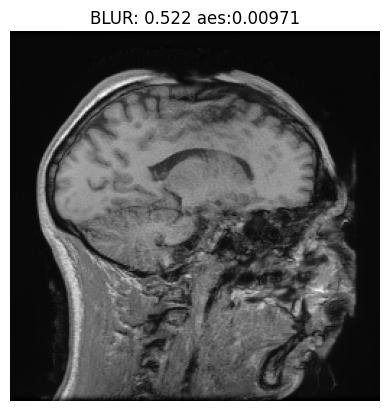

In [11]:
aa = input_img_3DNuFFT_sub2_run02
with torch.no_grad():
    t = 105#t+10
    print(t)

    Art = aa[:,t]
    print(Art.shape)
    Art = torch.tensor(ndimage.rotate(Art, -90))
    Art = abs(Art)[None][None]#.cuda()
    Art = norm_0_1(Art)

    with torch.no_grad():
        
        Real_out = model(Art) 
        #torch.save(Real_out[0,0,17:-17,:],'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Cycle_REAL.pt')
        print(b(Real_out))
        #plot_2_Imgs(Art,Real_out) 
plot_Img(Real_out)

BLUR: 0.579 aes:0.00912


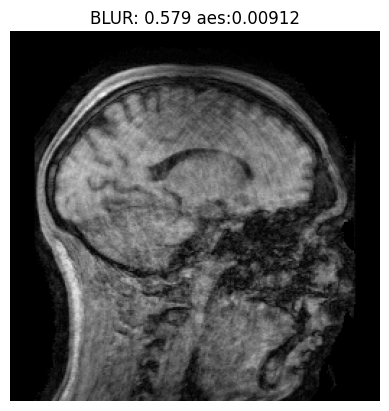

In [12]:
plot_Img(Art) 

BLUR: 0.493 aes:0.01951


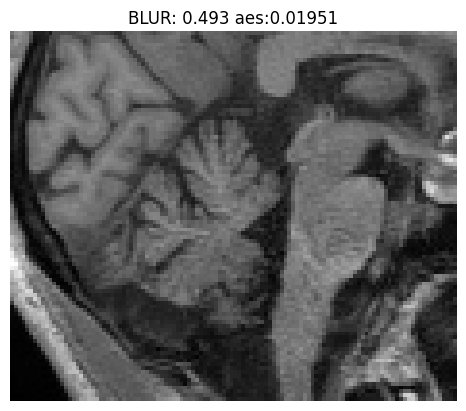

In [15]:
plot_Img(Real_out[0,0,90:-70,30:-110])

## Loss & Optimization

In [ ]:
from shared.GradualWarmupSchedulerFile import *
from shared.ssim import SSIM
import torch.nn as nn

SSIM_criterion = SSIM().cuda()
msee = nn.MSELoss()
learning_rate = 10**-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## Training

In [ ]:
num_epochs = 50

for epoch in range( num_epochs):
    model.train()
    ssim_all = 0

    pbar_train = tqdm(enumerate(dataloaders['train']), total=len(dataloaders['train']), position=0, leave=True)
    for (i, data) in pbar_train:

        optimizer.zero_grad()

        Art = Variable(data['Art']).to(device)
        Arr = Variable(data['Arr'].to(device))

        outputs_train = model(Art)

        loss_train = 1-SSIM_criterion(outputs_train, Arr)
        loss_train.backward()
        optimizer.step()


        ssim_all .append( float(SSIM_criterion(outputs_train, Arr).cpu().detach())

        if(i%10==0):
            if((i==0) and (epoch==0)):
                file1 = open(path_model + "log.txt", "w")
            else:
                file1 = open(path_model + "log.txt", "a")
            file1.write("Epoch: " + str(epoch)+ "  , step: " + str(i) + "  , SSIM: " + str(float(ssim_all/(i+1))) + "\n")
            file1.close()



    print("Train SSIM: " ,ssim_all/len(pbar_train))
    print( "epoch: " , epoch, 'lr: '+ str(optimizer.param_groups[0]['lr'])+ "\n")

    file1 = open(path_model + "log.txt", "a")
    file1.write("Epoch: " + str(epoch)+ "  , Train: " + "  , SSIM: " + str(float(ssim_all/len(pbar_train))) + "\n"+ 'lr: '+ str(optimizer.param_groups[0]['lr'])+ "\n")
    file1.close()

    torch.save(model, path_model+"/"+str(epoch)+"model.pt")


    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    with torch.no_grad():
      ssim_all = 0
      pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
      for (i, datatest) in pbar_test:

            Art = Variable(datatest['Art']).to(device)
            Arr = Variable(datatest['Arr'].to(device))
          
            outputs_test = model(Art)
            ssim_all +=  float(SSIM_criterion(outputs_test, Arr).cpu().detach())

      print("Test SSIM: " ,ssim_all/len(pbar_test))

      file1 = open(path_model + "log.txt", "a")
      file1.write("Epoch: " + str(epoch)+ "  , Test: " + "  , SSIM: " + str(float(ssim_all/len(pbar_test))) + "\n")
      file1.close()


SyntaxError: '(' was never closed (3299369385.py, line 22)

In [ ]:
from torcheval.metrics import PeakSignalNoiseRatio
metric = PeakSignalNoiseRatio()
from shared.ssim import SSIM
SSIM_criterion = SSIM().cuda()
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)
from shared.mutualInfo import mutual_information
import time

In [ ]:
with torch.no_grad():
  ssim_all = [] ; psnr_bef=[] ; ssim_all_bef = []
  psnr=[] ; BLUR = [] ; BLUR_BEF = []
  MI = [] ; MI_BEF = []   
  times = []

  pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
  for (i, datatest) in pbar_test:
        
        path_ = (datatest['path'])[0]
        Arr = Variable(datatest['Arr']).to(device)
        Art = Variable(datatest['Art']).to(device)
        
        a = time.time()
        outputs_test = model(Art)
        times.append(time.time()-a)

        ssim_all .append(  float(SSIM_criterion(outputs_test, Arr).cpu().detach()))
        ssim_all_bef .append( float(SSIM_criterion(Art, Arr).cpu().detach()))

        metric = PeakSignalNoiseRatio()
        metric.update(outputs_test, Arr)
        paft = float(metric.compute())
        psnr.append( paft)

        metric = PeakSignalNoiseRatio()
        metric.update(Art, Arr)
        pbef = float(metric.compute())
        psnr_bef.append( pbef)

        BLUR .append( torch.sum(b(outputs_test)).cpu().detach())
        BLUR_BEF  .append( torch.sum(b(Art)).cpu().detach())


        MI .append( mutual_information(Arr,outputs_test))
        MI_BEF .append( mutual_information(Arr,Art))

        # save
        if(i==0):do='w'
        else: do = 'a'
        p = '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/1_Unet_InstanceNorm/data/'
        with open(p+ 'ssim_all.txt', do) as f:
            f.write( str(float(SSIM_criterion(outputs_test, Arr).cpu().detach())) + "\n" )
        with open(p+ 'ssim_all_bef.txt', do) as f:
            f.write( str(float(SSIM_criterion(Art, Arr).cpu().detach())) + "\n" )

        with open(p+ 'psnr_all.txt', do) as f:
            f.write( str(paft) + "\n" )
        with open(p+ 'psnr_all_bef.txt', do) as f:
            f.write( str(pbef) + "\n" )

        with open(p+ 'blur_all.txt', do) as f:
            f.write( str(float(torch.sum(b(outputs_test)).cpu().detach()))  + "\n" )
        with open(p+ 'blur_all_bef.txt', do) as f:
            f.write( str(float(torch.sum(b(Art)).cpu().detach())) + "\n" )
        
        with open(p+ 'MI_all.txt', do) as f:
            f.write( str(float(mutual_information(Arr,outputs_test)))  + "\n" )
        with open(p+ 'MI_all_bef.txt', do) as f:
            f.write( str(float(mutual_information(Arr,Art))) + "\n" )
        
        with open(p+ 'path.txt', do) as f:
            f.write( path_ + "\n" )

100%|██████████| 1200/1200 [02:00<00:00,  9.97it/s]


In [ ]:
print("ssim aft std :",np.std(ssim_all), "ssim mean :",np.mean(ssim_all))
print("ssim bef std :",np.std(ssim_all_bef), "ssim mean :",np.mean(ssim_all_bef) ,"\n")

print("psnr aft std :",np.std(psnr), "psnr mean :",np.mean(psnr))
print("psnr bef std :",np.std(psnr_bef), "psnr mean :",np.mean(psnr_bef),"\n")

print("Blur aft std :",np.std(BLUR), "Blur mean :",np.mean(BLUR))
print("Blur bef std :",np.std(BLUR_BEF), "Blur mean :",np.mean(BLUR_BEF),"\n")

print("MI aft std :",np.std(MI), "MI mean :",np.mean(MI))
print("MI bef std :",np.std(MI_BEF), "MI mean :",np.mean(MI_BEF),"\n")

print("time std :",np.std(times), "MI mean :",np.mean(times),"\n")

ssim aft std : 0.05527361796903891 ssim mean : 0.9067869175473849
ssim bef std : 0.12453755104871833 ssim mean : 0.7658770545820395 

psnr aft std : 3.0551382938331484 psnr mean : 30.07340113957723
psnr bef std : 5.026714467870823 psnr mean : 25.071650342941282 

Blur aft std : 0.03324076 Blur mean : 0.43001008
Blur bef std : 0.021324178 Blur mean : 0.44909087 

MI aft std : 0.1760799108646768 MI mean : 1.235200979315029
MI bef std : 0.2738904738789271 MI mean : 1.003781371839761 

time std : 0.0019472192405769156 MI mean : 0.005085857113202413 

